# Predicting Electric Vehicle Purchases
## Playground Series - Season 6 Episode 9

In [32]:
## Data Understanding and Data Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve,confusion_matrix,ConfusionMatrixDisplay,classification_report

In [33]:
# Read all the dataset
train = pd.read_csv("/kaggle/input/datasets/atifmazhar/playground/train.csv")
test = pd.read_csv("/kaggle/input/datasets/atifmazhar/playground/test.csv")
sample_submission = pd.read_csv("/kaggle/input/datasets/atifmazhar/playground/sample_submission.csv")

In [34]:
train.shape,test.shape

((668665, 15), (286571, 14))

In [35]:
# Let's Understand the dataset
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No


In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [37]:
train.describe()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level
count,668665.00000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,334332.00000,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477
std,193027.10321,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119
min,0.00000,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,167166.00000,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000
50%,334332.00000,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000
75%,501498.00000,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000
max,668664.00000,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000


In [38]:
train.isnull().sum()

id                             0
Age                            0
Annual_Income_USD              0
Daily_Commute_km               0
Number_of_Cars_Owned           0
Charging_Stations_Near_Home    0
Charging_Stations_Near_Work    0
Environmental_Concern_Level    0
Gender                         0
City_Type                      0
Current_Car_Type               0
Home_Charging_Possible         0
Subsidy_Available              0
Range_Anxiety_Level            0
Will_Buy_EV                    0
dtype: int64

In [39]:
train.duplicated().sum()

np.int64(0)

In [40]:
train.dtypes

id                               int64
Age                              int64
Annual_Income_USD              float64
Daily_Commute_km               float64
Number_of_Cars_Owned             int64
Charging_Stations_Near_Home      int64
Charging_Stations_Near_Work      int64
Environmental_Concern_Level    float64
Gender                          object
City_Type                       object
Current_Car_Type                object
Home_Charging_Possible          object
Subsidy_Available               object
Range_Anxiety_Level             object
Will_Buy_EV                     object
dtype: object

In [41]:
train.columns.tolist()

['id',
 'Age',
 'Annual_Income_USD',
 'Daily_Commute_km',
 'Number_of_Cars_Owned',
 'Charging_Stations_Near_Home',
 'Charging_Stations_Near_Work',
 'Environmental_Concern_Level',
 'Gender',
 'City_Type',
 'Current_Car_Type',
 'Home_Charging_Possible',
 'Subsidy_Available',
 'Range_Anxiety_Level',
 'Will_Buy_EV']

In [42]:
## Target Variable value count
train["Will_Buy_EV"].value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

## Visualization


<Axes: xlabel='Will_Buy_EV', ylabel='count'>

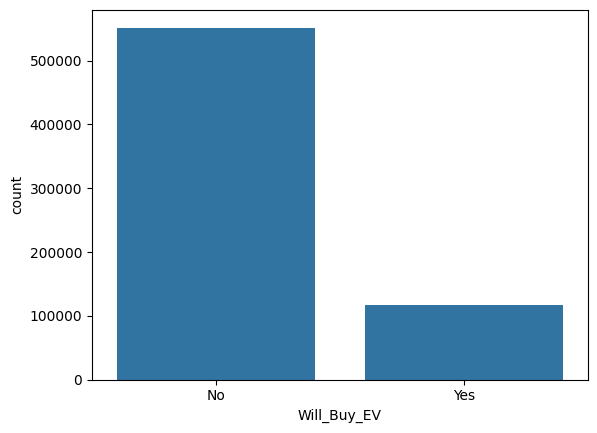

In [43]:
# Visualize the target distribution
sns.countplot(
    data = train,
    x = "Will_Buy_EV"
)

In [44]:
# Analyze the categorical columns

cat_features = train.select_dtypes(
    include = "object"
).columns

cat_features


Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='object')

In [45]:
for feature in cat_features:
    print("\n features")
    print("\n ",train[feature].value_counts())


 features

  Gender
Male      367954
Female    295427
Other       5284
Name: count, dtype: int64

 features

  City_Type
Urban       289305
Suburban    255377
Rural       123983
Name: count, dtype: int64

 features

  Current_Car_Type
Sedan        303459
SUV          246545
Hatchback     79438
Truck         39223
Name: count, dtype: int64

 features

  Home_Charging_Possible
Yes    462677
No     205988
Name: count, dtype: int64

 features

  Subsidy_Available
Yes    419909
No     248756
Name: count, dtype: int64

 features

  Range_Anxiety_Level
Low       603972
Medium     62499
High        2194
Name: count, dtype: int64

 features

  Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64


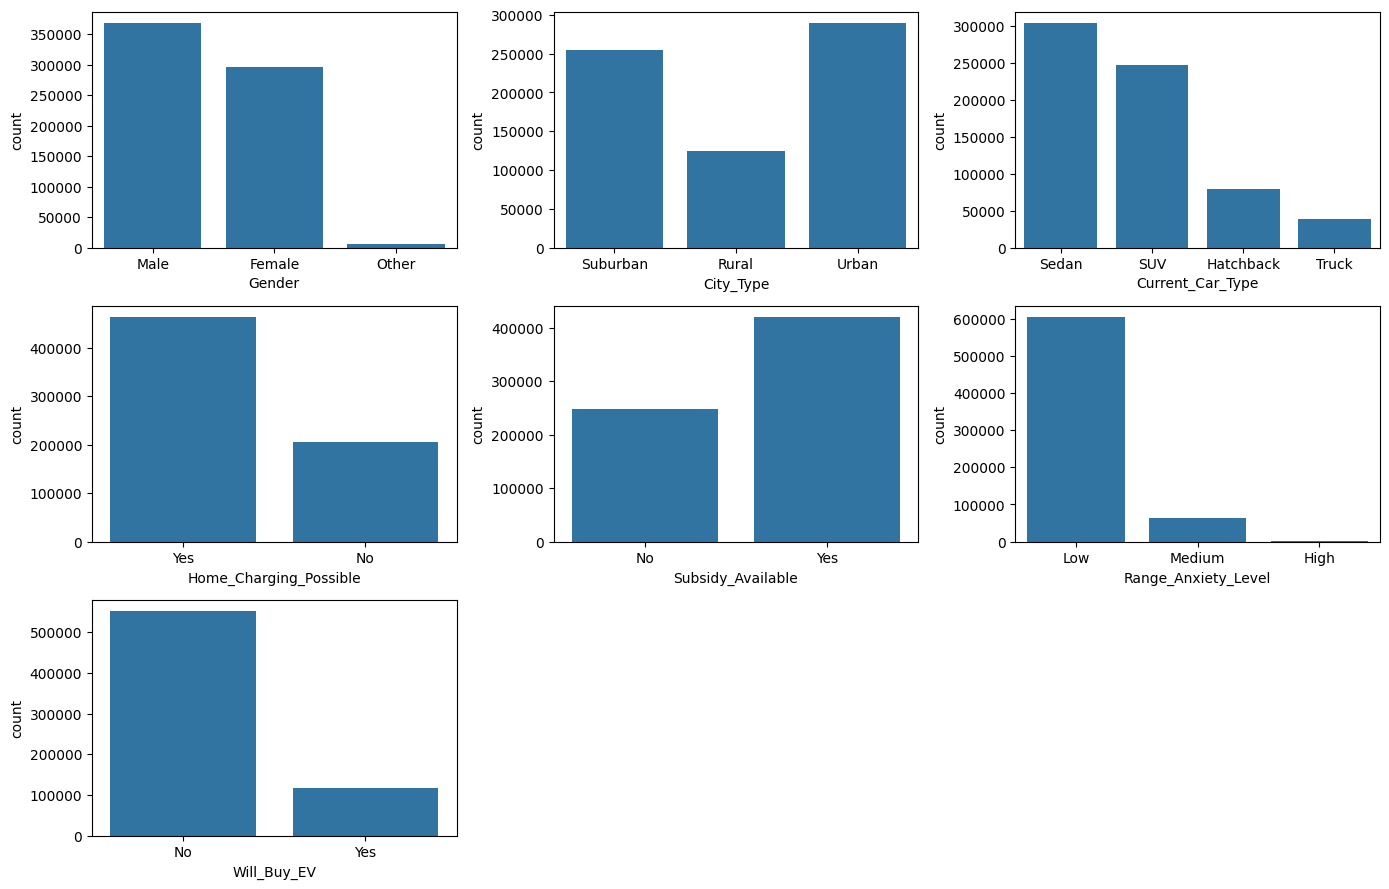

In [46]:
fig = plt.figure(figsize = (14,9))
i = 1
for feature in cat_features:
    fig.add_subplot(3,3,i)
    sns.countplot(
    data = train,
    x = feature
)
    i+=1
plt.tight_layout()

## Model Training

In [47]:
X = train.drop(["id","Will_Buy_EV"],
              axis =1)

y = train["Will_Buy_EV"]
X.shape,y.shape

((668665, 13), (668665,))

In [48]:
# Let's map our target variable values -> "Yes" : 1, "No" : 0
y = y.map(
    {
        "Yes":1,
        "No":0
    }
)

y.value_counts()

Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64

In [49]:
X_test_id = test["id"]
X_final_test = test.drop("id",axis =1)
X_final_test.columns,X_test.shape, X.shape

(Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
        'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
        'Environmental_Concern_Level', 'Gender', 'City_Type',
        'Current_Car_Type', 'Home_Charging_Possible', 'Subsidy_Available',
        'Range_Anxiety_Level'],
       dtype='object'),
 (133733, 24),
 (668665, 13))

In [50]:
# Split the train data set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42,stratify=y)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((534932, 13), (133733, 13), (534932,), (133733,))

In [51]:
### Let's deal with categorical and numerical columns
cat_features = X_train.select_dtypes(
    include = "object"
).columns
cat_features

Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
       'Subsidy_Available', 'Range_Anxiety_Level'],
      dtype='object')

In [52]:
num_features = X_train.select_dtypes(
    include = ["int64","float64"]
).columns
num_features

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level'],
      dtype='object')

In [53]:
# Let's encode the categorical variables

X_train = pd.get_dummies(
    X_train,
    columns = cat_features,
    dtype = int
)
X_train

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
616702,50,73410.0,54.1,2,5,9,2.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
68124,62,99265.0,5.0,2,12,15,5.0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
336079,37,104084.0,5.0,2,5,3,4.0,0,1,0,...,0,1,0,0,1,0,1,0,1,0
41616,45,107730.0,53.6,1,7,7,1.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
602048,56,91201.0,11.7,1,2,1,2.0,0,1,0,...,1,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272774,53,71929.0,48.5,2,2,2,2.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
45639,61,96530.0,21.1,1,7,3,4.0,1,0,0,...,1,0,0,0,1,1,0,0,1,0
592995,29,56835.0,5.0,1,2,3,1.0,1,0,0,...,0,1,0,0,1,1,0,0,1,0
295321,54,90909.0,24.2,2,3,9,3.0,0,1,0,...,1,0,0,0,1,1,0,0,1,0


In [54]:
X_test = pd.get_dummies(
    X_test,
    columns = cat_features,
    dtype = int
)
X_test

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
622494,68,30000.0,19.4,2,4,3,3.0,1,0,0,...,0,1,0,0,1,0,1,0,1,0
489984,66,96481.0,67.7,1,2,8,2.0,0,1,0,...,0,1,0,0,1,0,1,0,1,0
286947,57,93479.0,31.9,3,3,5,5.0,0,1,0,...,0,1,0,0,1,0,1,0,1,0
131933,40,76795.0,40.7,2,1,6,3.0,1,0,0,...,1,0,0,0,1,1,0,0,1,0
134987,54,74555.0,5.0,2,2,13,4.0,0,1,0,...,1,0,0,1,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9462,67,30000.0,36.7,2,10,6,4.0,0,1,0,...,0,1,0,1,0,0,1,0,0,1
479817,49,113828.0,49.8,2,7,8,4.0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
505782,46,123577.0,47.9,1,7,8,5.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
342319,49,90967.0,36.8,2,0,3,2.0,1,0,0,...,0,0,0,0,1,0,1,0,1,0


In [61]:
X_final_test = pd.get_dummies(
    X_final_test,
    columns = cat_features,
    dtype = int
)
X_final_test.columns

Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Environmental_Concern_Level', 'Gender_Female', 'Gender_Male',
       'Gender_Other', 'City_Type_Rural', 'City_Type_Suburban',
       'City_Type_Urban', 'Current_Car_Type_Hatchback', 'Current_Car_Type_SUV',
       'Current_Car_Type_Sedan', 'Current_Car_Type_Truck',
       'Home_Charging_Possible_No', 'Home_Charging_Possible_Yes',
       'Subsidy_Available_No', 'Subsidy_Available_Yes',
       'Range_Anxiety_Level_High', 'Range_Anxiety_Level_Low',
       'Range_Anxiety_Level_Medium'],
      dtype='object')

In [62]:
### Let's standardized the numerical features

scaler= StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])
X_final_test[num_features] = scaler.transform(X_final_test[num_features])

In [63]:
X_train

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
616702,0.231405,-0.396325,1.171858,0.395397,0.009944,0.352491,-0.654201,1,0,0,...,1,0,0,0,1,0,1,0,1,0
68124,1.163525,0.506942,-1.449613,0.395397,1.792569,1.510319,1.446055,1,0,0,...,0,1,0,1,0,0,1,0,1,0
336079,-0.778392,0.675298,-1.449613,0.395397,0.009944,-0.805337,0.745970,0,1,0,...,0,1,0,0,1,0,1,0,1,0
41616,-0.156978,0.802674,1.145163,-0.976864,0.519266,-0.033452,-1.354286,1,0,0,...,1,0,0,0,1,0,1,0,1,0
602048,0.697465,0.225219,-1.091897,-0.976864,-0.754038,-1.191280,-0.654201,0,1,0,...,1,0,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272774,0.464435,-0.448065,0.872871,0.395397,-0.754038,-0.998309,-0.654201,1,0,0,...,1,0,0,0,1,0,1,0,1,0
45639,1.085848,0.411392,-0.590027,-0.976864,0.519266,-0.805337,0.745970,1,0,0,...,1,0,0,0,1,1,0,0,1,0
592995,-1.399805,-0.975387,-1.449613,-0.976864,-0.754038,-0.805337,-1.354286,1,0,0,...,0,1,0,0,1,1,0,0,1,0
295321,0.542112,0.215018,-0.424517,0.395397,-0.499377,0.352491,0.045884,0,1,0,...,1,0,0,0,1,1,0,0,1,0


In [64]:
lr = LogisticRegression(
    max_iter= 1000,
    random_state=42
)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [81]:
y_pred = lr.predict(X_test)
y_prob = lr.predict_proba(X_test)[:,1]


In [68]:
y_pred[:10],y_test[:10].values

(array([0, 0, 1, 0, 0, 0, 0, 0, 1, 0]), array([0, 0, 1, 0, 0, 0, 0, 0, 1, 1]))

## Model Evaluation

In [82]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f" Accuracy : {accuracy}")
print(f"\n precision : {precision}")
print(f"\n recall : {recall}")
print(f"\n f1 Score: {f1}")
print(f"Roc Score:{roc_auc}")

 Accuracy : 0.8949174848391945

 precision : 0.716701607267645

 recall : 0.6586744305531769

 f1 Score: 0.6864639343165034
Roc Score:0.9379578769118007


In [83]:
report = classification_report(y_test,y_pred)
print("Classification Report")
print(report)

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.94      0.94    110377
           1       0.72      0.66      0.69     23356

    accuracy                           0.89    133733
   macro avg       0.82      0.80      0.81    133733
weighted avg       0.89      0.89      0.89    133733



In [84]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[104296,   6081],
       [  7972,  15384]])

Text(50.722222222222214, 0.5, 'Actual')

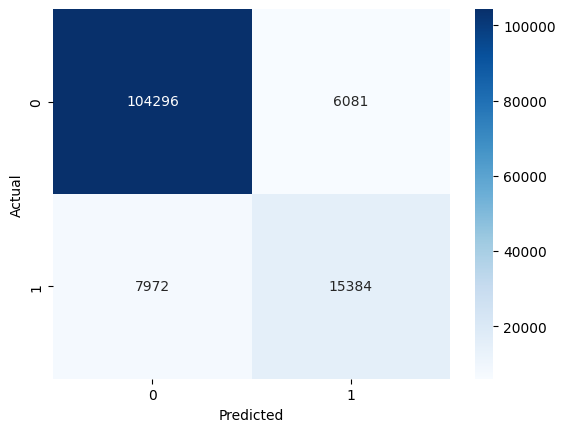

In [85]:
sns.heatmap(
    cm,
    annot=True,
    fmt = "d",
    cmap = "Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")

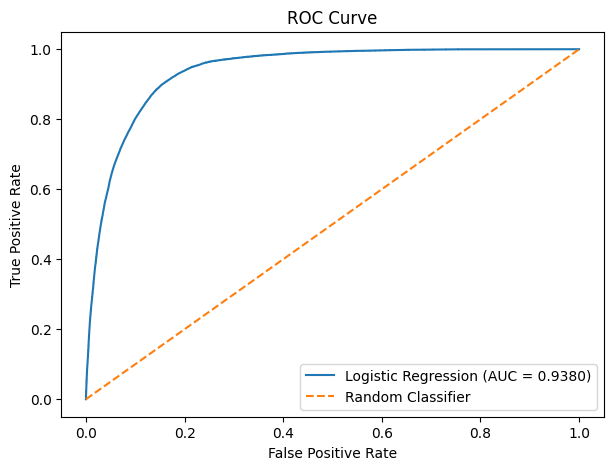

In [86]:
# Roc Curve
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

### Train the final model on all train data

In [88]:
X_final_test

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,1.085848,-0.594935,-0.814267,0.395397,0.519266,-0.612366,0.745970,0,1,0,...,0,1,0,0,1,1,0,0,1,0
1,-0.390008,2.378456,0.520494,0.395397,1.028587,0.352491,0.745970,0,1,0,...,1,0,0,1,0,1,0,0,1,0
2,1.629585,0.074156,1.129146,-0.976864,1.283248,0.738434,0.745970,1,0,0,...,0,1,0,1,0,1,0,0,1,0
3,-0.623038,-1.326178,0.104049,0.395397,-0.244716,0.159520,0.745970,1,0,0,...,0,1,0,0,1,1,0,0,1,0
4,0.619788,0.957859,1.337368,-0.976864,0.264605,-0.612366,-1.354286,1,0,0,...,0,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286566,1.241201,-0.311780,-0.440534,-0.976864,-0.499377,-0.805337,-1.354286,0,1,0,...,1,0,0,0,1,1,0,0,1,0
286567,-1.555158,-0.181364,1.230588,0.395397,0.519266,-0.419395,0.045884,0,1,0,...,0,1,0,0,1,0,1,0,1,0
286568,-1.322128,-1.277652,0.557868,1.767659,0.519266,-0.033452,0.745970,1,0,0,...,0,1,0,0,1,1,0,0,1,0
286569,-1.166775,0.806692,-1.449613,0.395397,2.301891,-0.033452,-1.354286,1,0,0,...,1,0,0,1,0,1,0,0,1,0


In [114]:
X_full = train.drop(["id","Will_Buy_EV"],
              axis =1)

y_full = train["Will_Buy_EV"]
X_full.shape,y_full.shape

((668665, 13), (668665,))

In [117]:
y_full.value_counts()

Will_Buy_EV
No     551886
Yes    116779
Name: count, dtype: int64

In [118]:
cat_features,num_features

(Index(['Gender', 'City_Type', 'Current_Car_Type', 'Home_Charging_Possible',
        'Subsidy_Available', 'Range_Anxiety_Level'],
       dtype='object'),
 Index(['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned',
        'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
        'Environmental_Concern_Level'],
       dtype='object'))

In [119]:
# Encode Categorical features
X_full = pd.get_dummies(
    X_full,
    columns = cat_features,
    dtype = int
)
X_full

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,66,92887.0,23.4,2,3,7,1.0,0,1,0,...,0,1,0,0,1,1,0,0,1,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,0,...,1,0,0,0,1,1,0,0,1,0
2,26,94389.0,36.8,1,8,15,5.0,1,0,0,...,0,1,0,1,0,0,1,0,1,0
3,66,73580.0,23.7,2,6,9,3.0,0,1,0,...,0,0,0,0,1,1,0,0,1,0
4,54,57898.0,50.8,1,2,3,3.0,0,1,0,...,0,0,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,1,0,...,0,1,0,1,0,0,1,0,0,1
668661,32,129990.0,5.0,2,5,4,1.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,0,...,0,0,0,0,1,0,1,0,1,0
668663,51,115923.0,43.7,2,0,0,1.0,1,0,0,...,1,0,0,0,1,0,1,0,1,0


In [120]:
# Standardized the numerical features
scaler = StandardScaler()
X_full[num_features] = scaler.fit_transform(X_full[num_features])
X_full

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender_Female,Gender_Male,Gender_Other,...,Current_Car_Type_SUV,Current_Car_Type_Sedan,Current_Car_Type_Truck,Home_Charging_Possible_No,Home_Charging_Possible_Yes,Subsidy_Available_No,Subsidy_Available_Yes,Range_Anxiety_Level_High,Range_Anxiety_Level_Low,Range_Anxiety_Level_Medium
0,1.472636,0.283361,-0.467597,0.394055,-0.499233,-0.033994,-1.354316,0,1,0,...,0,1,0,0,1,1,0,0,1,0
1,-0.702048,-1.911800,-1.449954,-0.977170,-0.753891,-0.998012,0.744881,0,1,0,...,1,0,0,0,1,1,0,0,1,0
2,-1.634055,0.335791,0.247816,-0.977170,0.774056,1.508436,1.444613,1,0,0,...,0,1,0,1,0,0,1,0,1,0
3,1.472636,-0.390577,-0.451580,0.394055,0.264740,0.351613,0.045149,0,1,0,...,0,0,0,0,1,1,0,0,1,0
4,0.540629,-0.937980,0.995261,-0.977170,-0.753891,-0.805209,0.045149,0,1,0,...,0,0,0,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,-1.323386,-0.477495,-0.254041,0.394055,0.010082,-0.226798,1.444613,0,1,0,...,0,1,0,1,0,0,1,0,0,1
668661,-1.168051,1.578495,-1.449954,0.394055,0.010082,-0.612405,-1.354316,1,0,0,...,1,0,0,0,1,0,1,0,1,0
668662,1.317301,1.292297,-0.424885,-0.977170,0.010082,-0.226798,-1.354316,1,0,0,...,0,0,0,0,1,0,1,0,1,0
668663,0.307627,1.087466,0.616200,0.394055,-1.263206,-1.383620,-1.354316,1,0,0,...,1,0,0,0,1,0,1,0,1,0


In [121]:
y_full = y_full.map({
    "Yes" : 1,
    "No" : 0
})
y_full.value_counts()

Will_Buy_EV
0    551886
1    116779
Name: count, dtype: int64

In [122]:
## Lets gooooo! Train final model
model = LogisticRegression(
    max_iter=1000,
    random_state = 42
)
model.fit(X_full,y_full)

LogisticRegression(max_iter=1000, random_state=42)

In [124]:
test_prob = model.predict_proba(X_final_test)[:,1]
test_prob[:10]

array([4.81610551e-03, 3.17056002e-02, 5.56205483e-03, 2.70665104e-03,
       2.26088504e-02, 2.81911535e-03, 4.17795434e-01, 1.11214758e-04,
       6.82659830e-01, 6.06693072e-03])

In [126]:
submission = pd.DataFrame(
    {
        "id": X_test_id,
        "Will_Buy_EV" : test_prob
    }
)
submission.head(),submission.shape

(       id  Will_Buy_EV
 0  668665     0.004816
 1  668666     0.031706
 2  668667     0.005562
 3  668668     0.002707
 4  668669     0.022609,
 (286571, 2))

In [127]:
submission.to_csv("Submission_logistic.csv",index = False)
